minAlpha = 0.0006551285568595509
--> minError=0.03543602760562309


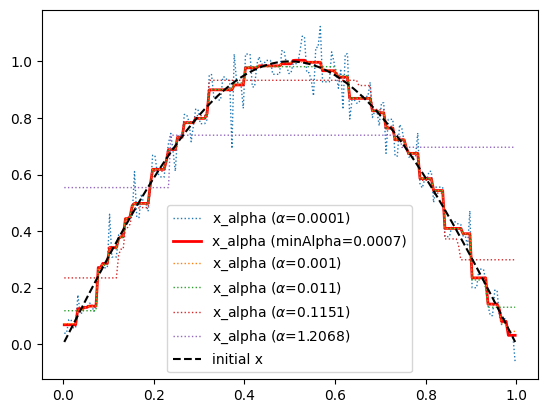

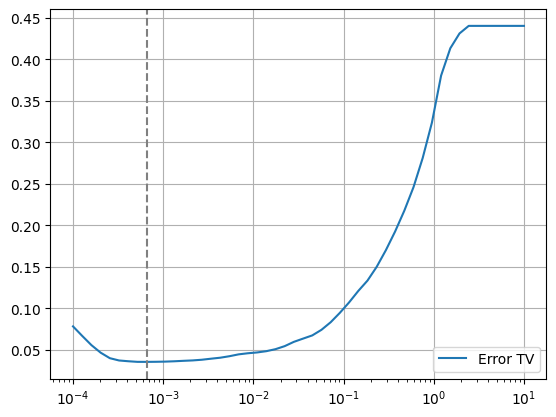

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def tv_primal_dual(A, L, b, lam):
    m, n = A.shape
    theta = 1.0

    # first derivative matrix*    D = np.diff(np.eye(n), axis=0)*
    # estimate ||K||
    K = np.vstack([A,L])
    lipc = np.linalg.norm(K, 2)
    tau = 0.99 / lipc
    sigma = 0.99 / lipc

    x = np.zeros(n)
    xbar = x.copy()

    pA = np.zeros(m)
    pL = np.zeros(n - 1)

    for k in range(5000):
        x_old = x.copy()

        # dual variable for data fidelity
        qA = pA + sigma * (A @ xbar)
        pA = (qA - sigma * b) / (1.0 + sigma)
        # dual variable for TV
        qL = pL + sigma * (L @ xbar)
        pL = np.clip(qL, -lam, lam)
        # primal update
        grad = A.T @ pA + L.T @ pL
        x = x - tau * grad
        # extrapolation
        xbar = x + theta * (x - x_old)
    
    return x


N = 200
#region L-Matrices
L1 = np.zeros((N-1,N))
L2 = np.zeros((N-2,N))

for i in range(N-2):
    L1[i,i] = -1
    L1[i,i+1] = 1

    L2[i,i] = 1
    L2[i,i+1] = -2
    L2[i,i+2] = 1

L1[N-2,N-2] = -1
L1[N-2,N-1] = 1
# endregion

def k(t,s):
    if s<t:
        return 1/np.sqrt(np.pi*(t-s))
    else:
        return 0

N = 200 #stepsize
h = 1/N

s_grid = np.array([i*h + h/2 for i in range(N)])
t_grid = np.array([i*h for i in range(1,N+1)])

A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        A[i,j] = h * k(t_grid[i], s_grid[j])

# FUNCTION
x = lambda s: np.sin( s*np.pi )

x_grid = x(s_grid)
y_grid = A @ x_grid

np.random.seed(42)
d = np.random.randn(N)
d = d/np.linalg.norm(d) * np.linalg.norm(y_grid) * 0.01
y_delta = y_grid + d

ktop = min(50,N)
a_array = 10**np.linspace(-4,1,ktop)
x_alphas1 = np.zeros((len(a_array),N))
error_TV = np.zeros( len(a_array) )


for i, a in enumerate(a_array):
    x_alphas1[i,:] = tv_primal_dual(A, L1, y_delta, a)
    error_TV[i] = np.linalg.norm(x_grid - x_alphas1[i])/np.linalg.norm(x_grid)
    if i%10==0:
        plt.plot(s_grid,x_alphas1[i,:],label=f"x_alpha ($\\alpha$={round(a,4)})",linestyle=':',lw=1)
    if 0.00064 <= a <= 0.00066:
        plt.plot(s_grid,x_alphas1[i,:],color='red',label=f'x_alpha (minAlpha={round(a,4)})',lw=2,linestyle="-")

indexError = np.argmin(error_TV)
minError = min(error_TV)
min_alpha = a_array[indexError]

print(f"minAlpha = {min_alpha}\n--> minError={minError}")

plt.plot(s_grid,x_grid,label="initial x",color='black',linestyle='--')
plt.legend()
plt.show()

plt.semilogx(a_array,error_TV,label="Error TV")
plt.axvline(min_alpha,color="grey",linestyle="--")
plt.grid(True)
plt.legend()
plt.show()